# Disaster Tweets — a linear baseline: TF-IDF + logistic regression

Every later model is compared against this baseline's out-of-fold F1 on the same five stratified folds (saved to
`results/folds.csv`). F1 depends on the decision threshold, so the threshold is chosen on out-of-fold probabilities only,
and its uncertainty is reported with a bootstrap over tweets.

In [1]:
import re, json, time, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import sparse
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, precision_recall_curve, roc_curve, brier_score_loss, confusion_matrix,
                             roc_auc_score, average_precision_score, precision_score, recall_score)
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52"]; RS = 42
os.makedirs("assets", exist_ok=True); os.makedirs("results", exist_ok=True)
train = pd.read_csv("data/train.csv"); test = pd.read_csv("data/test.csv"); y = train.target.values

from nlp_common import norm, model_text
X_text, T_text = model_text(train), model_text(test)

## 1. Folds and features (fitted on each fold's training rows only)

Features: word 1–2-grams (with the keyword as a special token), character 2–5-grams. Fitted once per fold and reused
across the regularisation sweep, the ablation and the learning curve.

In [2]:
skf = StratifiedKFold(5, shuffle=True, random_state=RS); folds = np.zeros(len(train), int)
for k, (_, va) in enumerate(skf.split(X_text, y)): folds[va] = k
pd.DataFrame({"id": train.id, "fold": folds}).to_csv("results/folds.csv", index=False)

def featurize(fit_text, *others):
    wv = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    cv = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=40000)
    Xw, Xc = wv.fit_transform(fit_text), cv.fit_transform(fit_text)
    outs = [sparse.hstack([Xw, Xc]).tocsr()] + [sparse.hstack([wv.transform(o), cv.transform(o)]).tocsr() for o in others]
    return outs, Xw.shape[1], wv, cv

t0 = time.time(); FM = {}
for k in range(5):
    (Xa, Xb), nw, _, _ = featurize(X_text[folds != k], X_text[folds == k]); FM[k] = (Xa, Xb, nw)
print(f"features for 5 folds in {time.time()-t0:.1f}s; fold 0: {FM[0][0].shape[1]} columns ({FM[0][2]} word, rest char)")
def fit_oof(C_, cols=None):
    p_ = np.zeros(len(train))
    for k in range(5):
        Xa, Xb, nw = FM[k]; sl = slice(None) if cols is None else cols(nw, Xa.shape[1])
        p_[folds == k] = LogisticRegression(C=C_, solver="liblinear", max_iter=500).fit(Xa[:, sl], y[folds != k]).predict_proba(Xb[:, sl])[:, 1]
    return p_

features for 5 folds in 9.0s; fold 0: 46077 columns (15544 word, rest char)


## 2. Regularisation sweep and feature-group ablation

    C  f1_at_05    auc  logloss
 0.25    0.7607 0.8693   0.4822
 0.50    0.7681 0.8731   0.4532
 1.00    0.7697 0.8745   0.4349
 2.00    0.7710 0.8736   0.4279
 4.00    0.7684 0.8709   0.4330
 8.00    0.7627 0.8673   0.4508
16.00    0.7594 0.8640   0.4810
best C = 2.0 (22.2s)


                        f1_at_05     auc
word n-grams only         0.7606  0.8659
character n-grams only    0.7658  0.8734
word + character          0.7710  0.8736


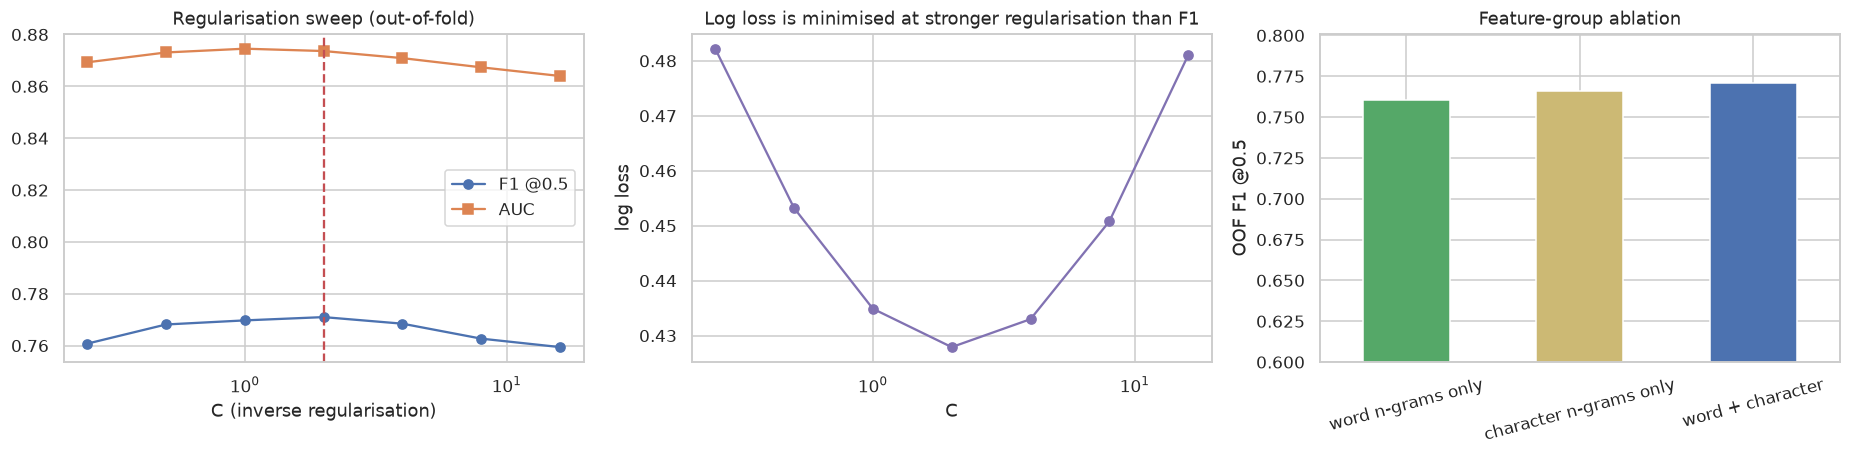

In [3]:
t0 = time.time(); sweep = []; probs = {}
for C_ in [0.25, 0.5, 1, 2, 4, 8, 16]:
    probs[C_] = fit_oof(C_); sweep.append(dict(C=C_, f1_at_05=f1_score(y, probs[C_] > .5), auc=roc_auc_score(y, probs[C_]), logloss=-np.mean(y*np.log(probs[C_]) + (1-y)*np.log(1-probs[C_]))))
sweep = pd.DataFrame(sweep); best_C = float(sweep.loc[sweep.f1_at_05.idxmax(), "C"]); oof = probs[best_C]; print(sweep.round(4).to_string(index=False)); print(f"best C = {best_C} ({time.time()-t0:.1f}s)")
abl = {"word n-grams only": fit_oof(best_C, lambda nw, n: slice(0, nw)), "character n-grams only": fit_oof(best_C, lambda nw, n: slice(nw, n)), "word + character": oof}
abl_df = pd.DataFrame({k: dict(f1_at_05=f1_score(y, v > .5), auc=roc_auc_score(y, v)) for k, v in abl.items()}).T; print(abl_df.round(4))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
axes[0].semilogx(sweep.C, sweep.f1_at_05, "o-", label="F1 @0.5"); axes[0].semilogx(sweep.C, sweep.auc, "s-", label="AUC"); axes[0].axvline(best_C, color="r", ls="--")
axes[0].set_xlabel("C (inverse regularisation)"); axes[0].set_title("Regularisation sweep (out-of-fold)"); axes[0].legend()
axes[1].semilogx(sweep.C, sweep.logloss, "o-", color="#8172B2"); axes[1].set_xlabel("C"); axes[1].set_ylabel("log loss"); axes[1].set_title("Log loss is minimised at stronger regularisation than F1")
abl_df.f1_at_05.plot.bar(ax=axes[2], rot=15, color=["#55A868", "#CCB974", PAL[0]]); axes[2].set_ylim(.6, abl_df.f1_at_05.max() + .03); axes[2].set_ylabel("OOF F1 @0.5"); axes[2].set_title("Feature-group ablation")
plt.tight_layout(); plt.savefig("assets/v1_sweep_ablation.png", bbox_inches="tight"); plt.show()

## 3. Threshold, bootstrap interval, per-fold stability

In [4]:
ths = np.linspace(0.2, 0.8, 61); f1s = [f1_score(y, oof > t) for t in ths]; th = float(ths[int(np.argmax(f1s))])
rng = np.random.default_rng(RS); boot = []
for _ in range(500): i = rng.integers(0, len(y), len(y)); boot.append(f1_score(y[i], oof[i] > th))
lo, hi = np.percentile(boot, [2.5, 97.5]); fold_f1 = [f1_score(y[folds == k], oof[folds == k] > th) for k in range(5)]
res = dict(model="tfidf_logreg", C=best_C, threshold=th, oof_f1=f1_score(y, oof > th), oof_f1_ci95=[lo, hi], oof_f1_at_05=f1_score(y, oof > .5),
           oof_precision=precision_score(y, oof > th), oof_recall=recall_score(y, oof > th), oof_auc=roc_auc_score(y, oof),
           oof_ap=average_precision_score(y, oof), brier=brier_score_loss(y, oof), fold_f1=fold_f1)
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in res.items()}))
json.dump(res, open("results/v1_tfidf_eval.json", "w"), indent=2); np.save("results/v1_tfidf_oof.npy", oof)

{"model": "tfidf_logreg", "C": 2.0, "threshold": 0.45, "oof_f1": 0.7717, "oof_f1_ci95": [0.7615404915754985, 0.7827947306022464], "oof_f1_at_05": 0.771, "oof_precision": 0.7893, "oof_recall": 0.7548, "oof_auc": 0.8736, "oof_ap": 0.8715, "brier": 0.1355, "fold_f1": [0.7871170463472114, 0.7749019607843137, 0.7553846153846154, 0.7623529411764706, 0.7789968652037618]}


## 4. Post-training diagnostics

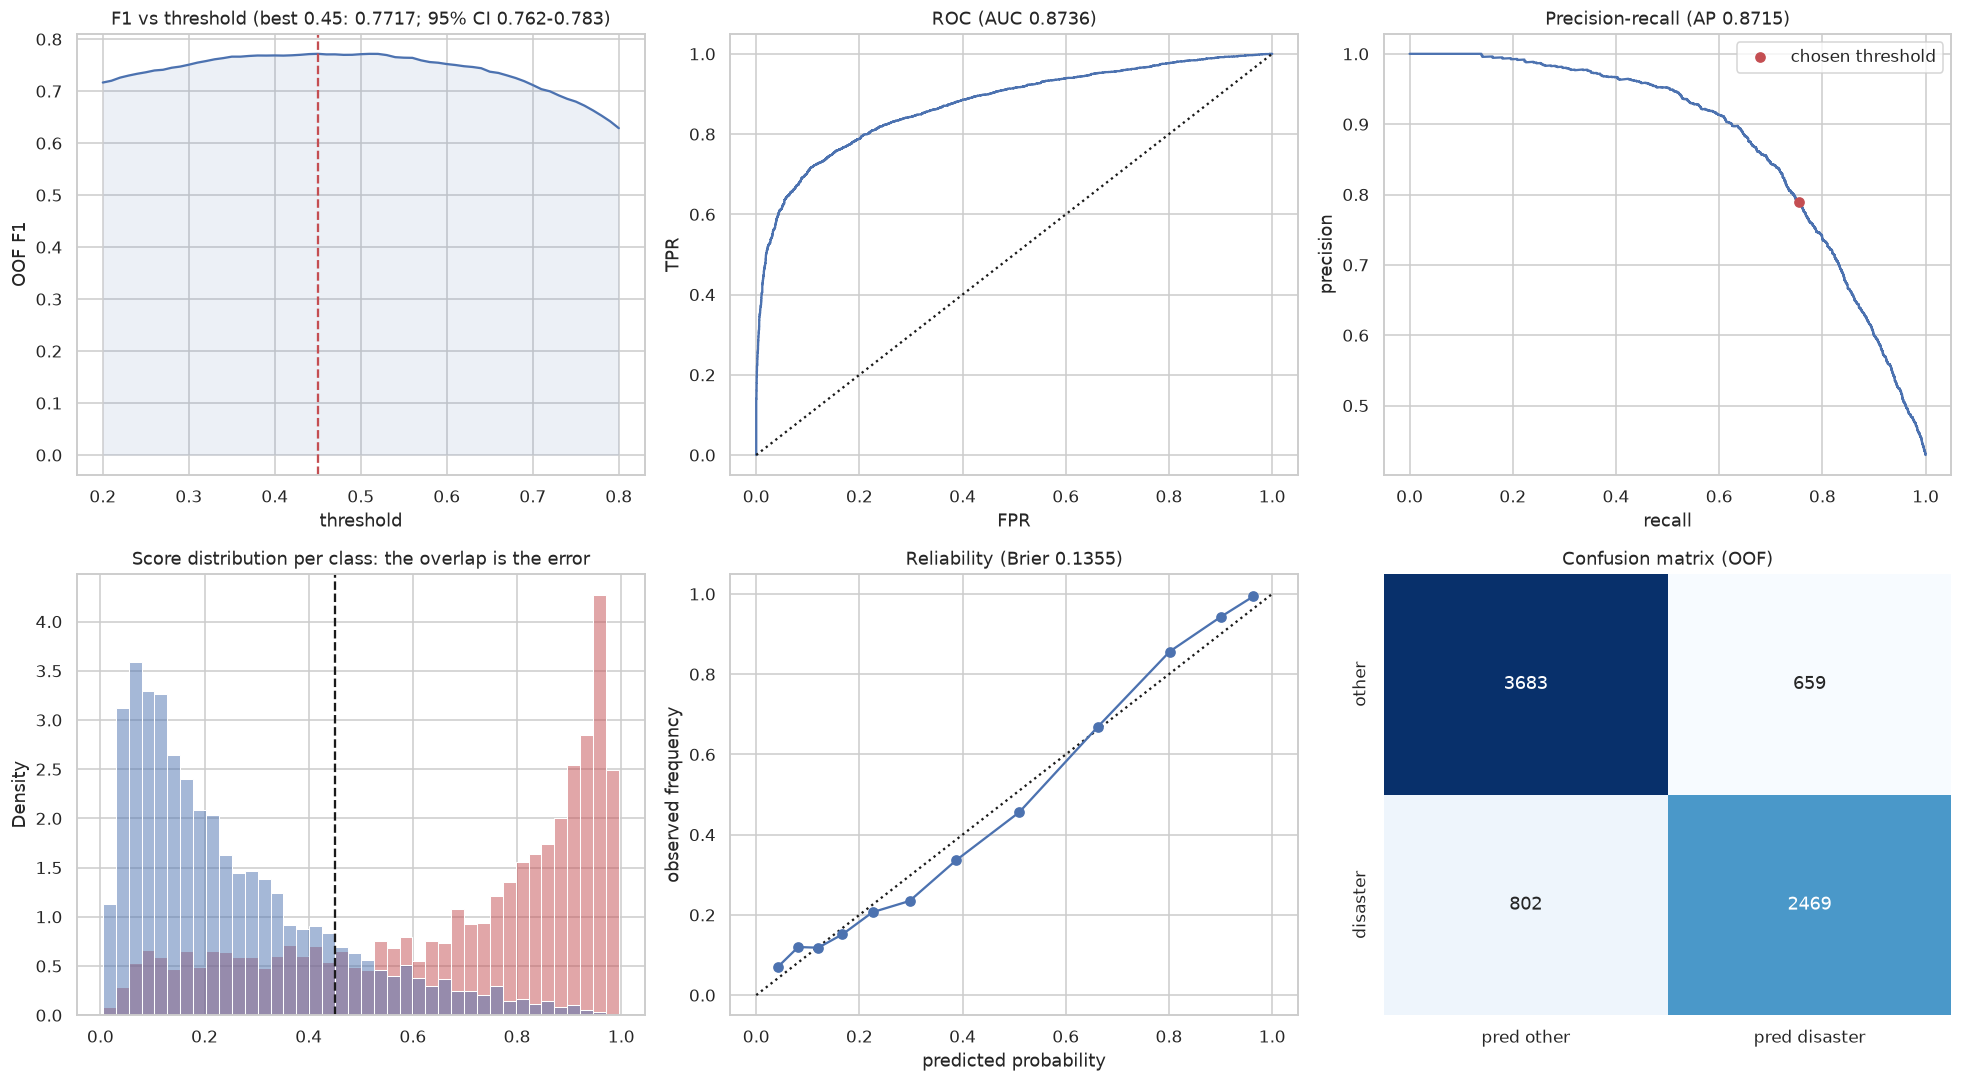

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].plot(ths, f1s); axes[0, 0].axvline(th, color="r", ls="--"); axes[0, 0].fill_between(ths, [f1_score(y, oof > t) for t in ths], alpha=.1)
axes[0, 0].set_xlabel("threshold"); axes[0, 0].set_ylabel("OOF F1"); axes[0, 0].set_title(f"F1 vs threshold (best {th:.2f}: {max(f1s):.4f}; 95% CI {lo:.3f}-{hi:.3f})")
fpr, tpr, _ = roc_curve(y, oof); axes[0, 1].plot(fpr, tpr); axes[0, 1].plot([0, 1], [0, 1], "k:"); axes[0, 1].set_xlabel("FPR"); axes[0, 1].set_ylabel("TPR"); axes[0, 1].set_title(f"ROC (AUC {res['oof_auc']:.4f})")
pr, rc, _ = precision_recall_curve(y, oof); axes[0, 2].plot(rc, pr); axes[0, 2].scatter([res["oof_recall"]], [res["oof_precision"]], color="r", zorder=3, label="chosen threshold")
axes[0, 2].set_xlabel("recall"); axes[0, 2].set_ylabel("precision"); axes[0, 2].set_title(f"Precision-recall (AP {res['oof_ap']:.4f})"); axes[0, 2].legend()
sns.histplot(x=oof, hue=y, bins=40, stat="density", common_norm=False, palette=PAL, ax=axes[1, 0], legend=False); axes[1, 0].axvline(th, color="k", ls="--"); axes[1, 0].set_title("Score distribution per class: the overlap is the error")
fp, mp = calibration_curve(y, oof, n_bins=12, strategy="quantile"); axes[1, 1].plot([0, 1], [0, 1], "k:"); axes[1, 1].plot(mp, fp, "o-")
axes[1, 1].set_xlabel("predicted probability"); axes[1, 1].set_ylabel("observed frequency"); axes[1, 1].set_title(f"Reliability (Brier {res['brier']:.4f})")
cm = confusion_matrix(y, oof > th); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 2], cbar=False, xticklabels=["pred other", "pred disaster"], yticklabels=["other", "disaster"]); axes[1, 2].set_title("Confusion matrix (OOF)")
plt.tight_layout(); plt.savefig("assets/v1_diagnostics_grid.png", bbox_inches="tight"); plt.show()

### What the model learned: largest coefficients (fit on all training rows)

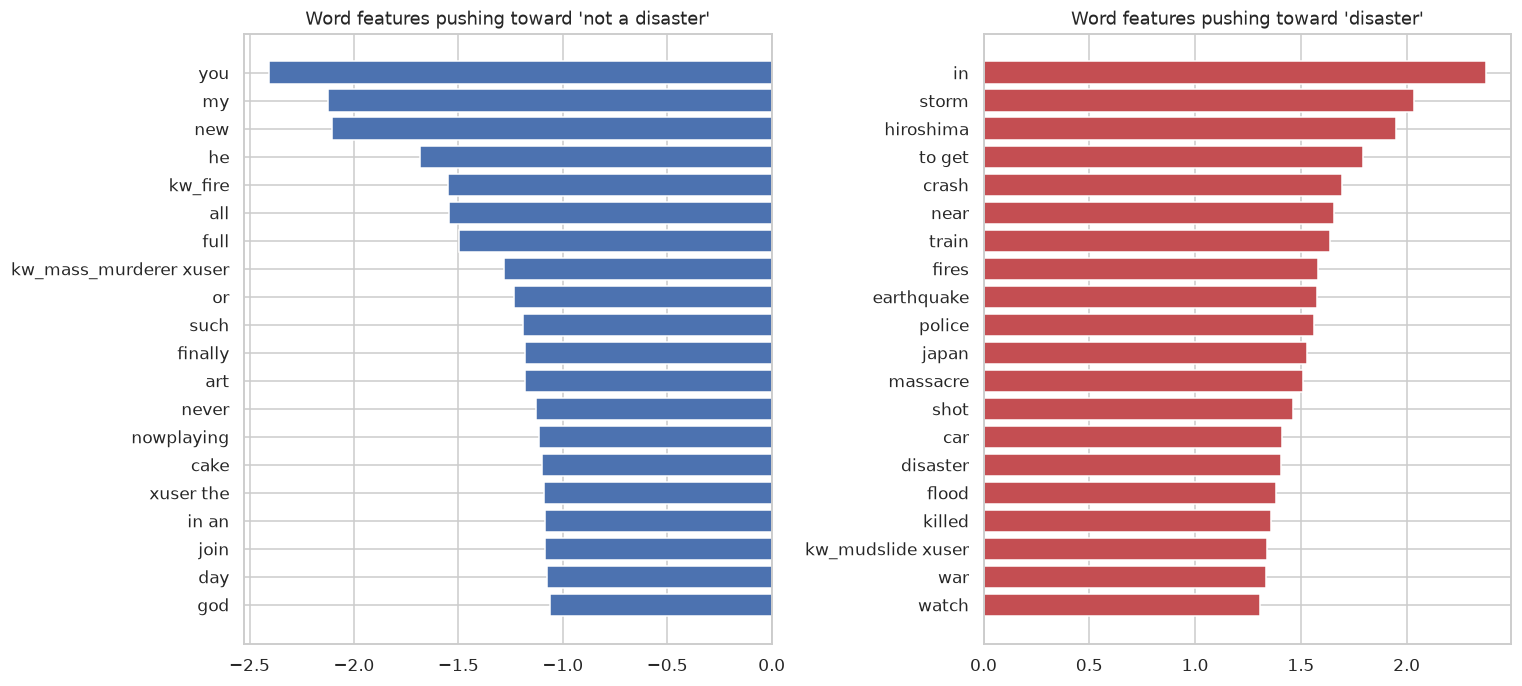

active features: 52714 of 52714 | keyword tokens in the 30 strongest word features: 2


In [6]:
(Xall, Xtest_), nw_all, wv_all, cv_all = featurize(X_text, T_text)
lr_all = LogisticRegression(C=best_C, solver="liblinear", max_iter=500).fit(Xall, y)
names = np.array(list(wv_all.get_feature_names_out()) + ["char:" + n for n in cv_all.get_feature_names_out()]); coef = lr_all.coef_[0]
wmask = np.arange(len(names)) < nw_all; order = np.argsort(coef[wmask]); wn, wc = names[wmask][order], coef[wmask][order]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
axes[0].barh(wn[:20][::-1], wc[:20][::-1], color=PAL[0]); axes[0].set_title("Word features pushing toward 'not a disaster'")
axes[1].barh(wn[-20:], wc[-20:], color=PAL[1]); axes[1].set_title("Word features pushing toward 'disaster'")
plt.tight_layout(); plt.savefig("assets/v1_coefficients.png", bbox_inches="tight"); plt.show()
print("active features:", int((coef != 0).sum()), "of", len(coef), "| keyword tokens in the 30 strongest word features:", int(sum(n.startswith("kw_") for n in wn[:15]) + sum(n.startswith("kw_") for n in wn[-15:])))

### Learning curve and where the errors are

 n_train     f1     sd
     609 0.6959 0.0253
    1218 0.7354 0.0136
    2131 0.7512 0.0098
    3045 0.7590 0.0123
    4263 0.7688 0.0077
    6090 0.7718 0.0114


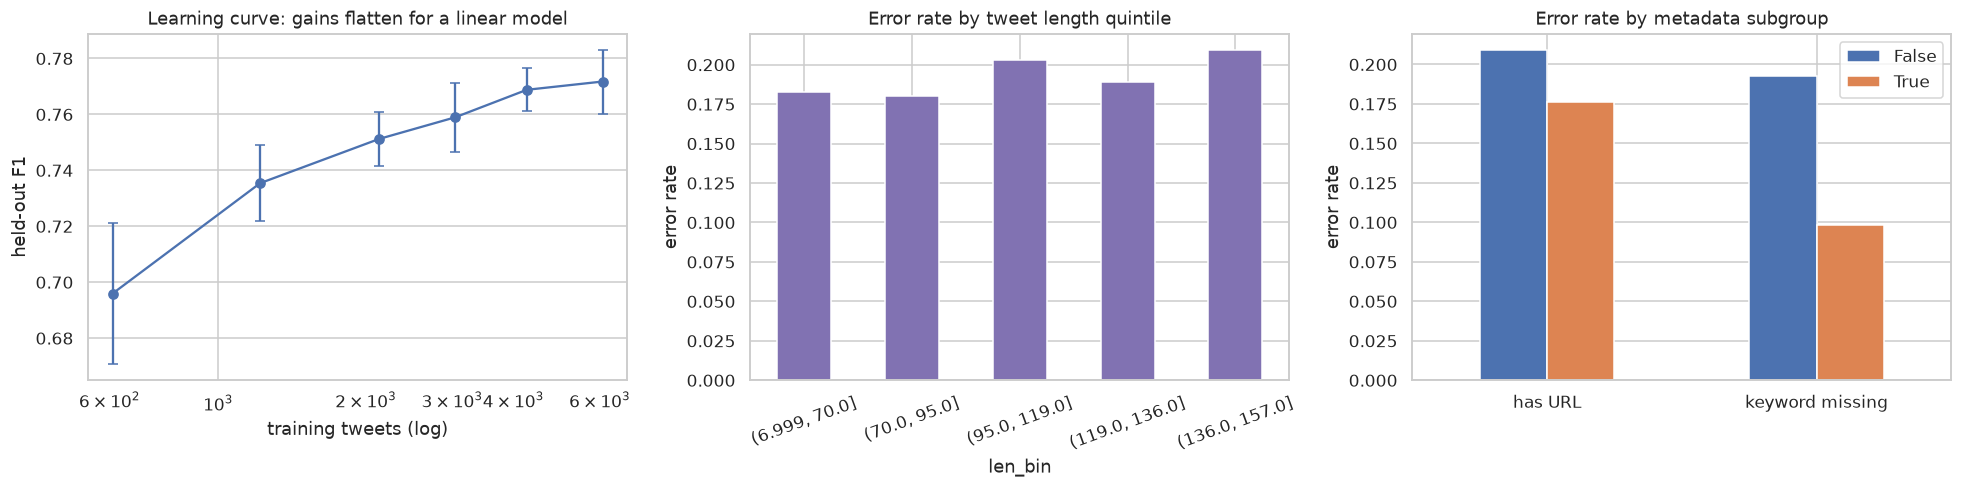

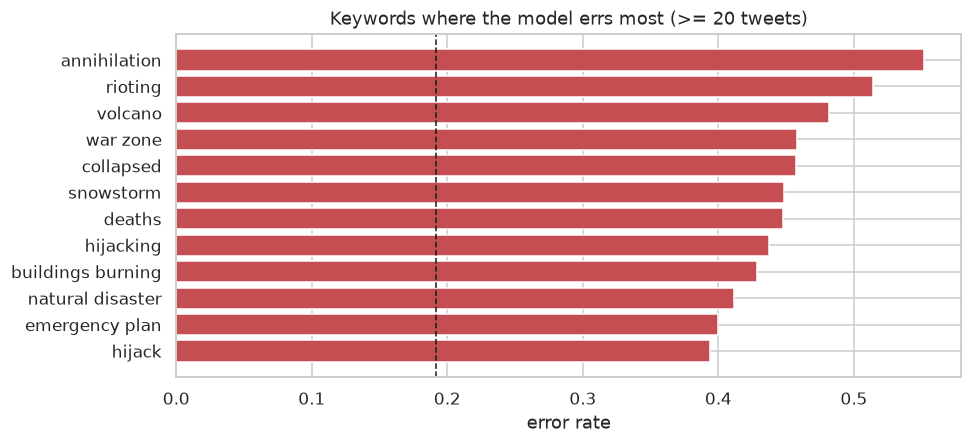

In [7]:
fracs = [0.1, 0.2, 0.35, 0.5, 0.7, 1.0]; lc = []
for f in fracs:
    sc = []
    for k in range(5):
        Xa, Xb, nw = FM[k]; ytr = y[folds != k]; sub = np.random.default_rng(k).choice(len(ytr), int(f * len(ytr)), replace=False)
        p_ = LogisticRegression(C=best_C, solver="liblinear", max_iter=500).fit(Xa[sub], ytr[sub]).predict_proba(Xb)[:, 1]; sc.append(f1_score(y[folds == k], p_ > th))
    lc.append((int(f * len(train) * 0.8), np.mean(sc), np.std(sc)))
lc = pd.DataFrame(lc, columns=["n_train", "f1", "sd"]); print(lc.round(4).to_string(index=False))
err = train.assign(p=oof, pred=(oof > th).astype(int)); err["wrong"] = err.pred != err.target
err["has_url"] = err.text.str.contains("http"); err["len_bin"] = pd.qcut(err.text.str.len(), 5); err["kw_missing"] = err.keyword.isna()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
axes[0].errorbar(lc.n_train, lc.f1, yerr=lc.sd, marker="o", capsize=3); axes[0].set_xscale("log"); axes[0].set_xlabel("training tweets (log)"); axes[0].set_ylabel("held-out F1"); axes[0].set_title("Learning curve: gains flatten for a linear model")
err.groupby("len_bin", observed=True).wrong.mean().plot.bar(ax=axes[1], rot=20, color="#8172B2"); axes[1].set_ylabel("error rate"); axes[1].set_title("Error rate by tweet length quintile")
sub_ = pd.DataFrame({"has URL": err.groupby("has_url").wrong.mean(), "keyword missing": err.groupby("kw_missing").wrong.mean()}).T; sub_.columns = ["False", "True"]
sub_.plot.bar(ax=axes[2], rot=0); axes[2].set_ylabel("error rate"); axes[2].set_title("Error rate by metadata subgroup")
plt.tight_layout(); plt.savefig("assets/v1_learning_curve_error_slices.png", bbox_inches="tight"); plt.show()
kwe = err.dropna(subset=["keyword"]).groupby("keyword").agg(n=("wrong", "size"), err=("wrong", "mean")).query("n >= 20").sort_values("err", ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 4.2)); ax.barh(kwe.index.str.replace("%20", " ")[::-1], kwe.err[::-1], color=PAL[1]); ax.axvline(err.wrong.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("error rate"); ax.set_title("Keywords where the model errs most (>= 20 tweets)"); plt.tight_layout(); plt.savefig("assets/v1_keyword_error_rate.png", bbox_inches="tight"); plt.show()

In [8]:
pd.set_option("display.max_colwidth", 110)
print("Most confident false positives (labelled not-disaster):"); display(err[err.target == 0].nlargest(8, "p")[["keyword", "text", "p"]])
print("Most confident false negatives (labelled disaster):"); display(err[err.target == 1].nsmallest(8, "p")[["keyword", "text", "p"]])
conf_texts = set(train.groupby("text").target.nunique().loc[lambda s: s > 1].index); inc = train.text.isin(conf_texts).values
print(f"OOF F1 excluding the {inc.sum()} rows with conflicting duplicate labels: {f1_score(y[~inc], oof[~inc] > th):.4f}")

Most confident false positives (labelled not-disaster):


,keyword,text,p
5435,police,Maid charged with stealing Dh30000 from police officer sponsor http://t.co/y35qtVDSOH | https://t.co/qhUJA...,0.953155
2877,drought,Large rain drops falling in Rock Hill off Anderson Road. #rain #scwx #drought,0.952476
5113,nuclear%20disaster,Over half of poll respondents worry nuclear disaster fading from public consciousness http://t.co/YtnnnD63...,0.947394
3057,earthquake,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a....,0.941773
5641,refugees,wowo--=== 12000 Nigerian refugees repatriated from Cameroon,0.936754
4055,forest%20fires,Tales of the #trees #deep water loving #Lake Tahoe. And no #forest fires https://t.co/xuhMJ098Lq,0.932247
3991,floods,@madonnamking RSPCA site multiple 7 story high rise buildings next to low density character residential in...,0.927630
3363,evacuation,FAAN orders evacuation of abandoned aircraft at MMA http://t.co/dEvYbnVXGQ via @todayng,0.927562


Most confident false negatives (labelled disaster):


,keyword,text,p
4154,harm,You can never escape me. Bullets don't harm me. Nothing harms me. But I know pain. I know pain. Sometimes ...,0.013997
649,blaze,Love living on my own. I can blaze inside my apt or on the balcony,0.015761
1847,crush,'@jorrynja: 6. @ your bf/gf/crush ??' @Ter_ell ??,0.022440
4732,lava,Check out my Lava lamp dude ???? http://t.co/To9ViqooFv,0.026025
5411,panicking,all that panicking made me tired ;__; i want to sleep in my bed,0.027011
974,body%20bag,?? New Ladies Shoulder Tote #Handbag Faux Leather Hobo Purse Cross Body Bag #Womens http://t.co/zujwUiomb3...,0.028260
2905,drown,I can't drown my demons they know how to swim,0.028704
4143,harm,@leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of you! Listen &amp...,0.029600


OOF F1 excluding the 55 rows with conflicting duplicate labels: 0.7750


## 5. Submission: refit on all training tweets, apply the out-of-fold threshold

In [9]:
pt = lr_all.predict_proba(Xtest_)[:, 1]; np.save("results/v1_tfidf_test_proba.npy", pt)
sub = pd.DataFrame({"id": test.id, "target": (pt > th).astype(int)}); sub.to_csv("submission_v1_tfidf.csv", index=False)
print(sub.shape, "predicted positive rate", round(sub.target.mean(), 4), "(train rate", round(y.mean(), 4), ")")

(3263, 2) predicted positive rate 0.4006 (train rate 0.4297 )
